### Stwp 1: Import libraries. ###

In [2]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization

import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")
print(f"TensorFlow version: {tf.__version__}")

✅ Libraries imported successfully!
TensorFlow version: 2.17.0


### Step 2: Data Exloration (EDA) and Cleaning ###

In [7]:
#-- Load dataset --#
df = pd.read_csv('../Processed/efficiency_stations.csv')
print("✅ Dataset loaded successfully!")

#-- Check for first 5 rows. --#
print("First 5 rows of the dataset:")
display(df.head())

#-- Check for missing values. --#
print("\n--- Missing Values ---")
print(df.isnull().sum())

#-- Descriptive Statistics. --#
print("\n--- Descriptive Statistics ---")
display(df.describe())

#-- Check unique stations. --#
n_stations = df['tfm_id'].nunique()
print(f"\n📊 Total unique stations: {n_stations}")

✅ Dataset loaded successfully!
First 5 rows of the dataset:


,x,y,fid,objectid,tfm_id,tfm_desc,tfm_typ_de,movement_t,site_desc,road_nbr,...,time_categ,year_since,last_year,aadt_allve,aadt_truck,per_trucks,road_name,road_avg_aadt,efficiency_index,vs_average_pct
0,144.560081,-37.968598,45122,45324,42013,PRINCES FWY WB ON-RAMP FROM SOUTH RD,MIDBLOCK,On Ramp,PRINCES FWY ON-RAMP FROM SOUTH RD,7024,...,Greater than 10 Years,18,1998,40,0,0.21,160 SOUTH ROADB 2500F,40.0,1.00,0.0
1,145.088615,-37.881431,55947,55189,52075,MONASH FWY OUTBOUND OFFRAMP TO WARRIGAL RD,INTERSECTION,Off Ramp,SVO_Map_LTD:838||SITE DESC: MONASH FWY OUTBOUN...,7138,...,Between 5 and 10 Years,10,2006,13000,0,0.00,2000F 2070B,5350.0,2.43,143.0
2,145.090058,-37.882231,38735,38966,36894,S.E.ARTERIAL OFF RAMP NW OF WARRIGAL RD,INTERSECTION,Off Ramp,S.E.ARTERIAL SEBD RAMPS & WARRIGAL RD,7138,...,Greater than 10 Years,19,1997,8400,640,0.08,2000F 2070B,5350.0,1.57,57.0
3,145.088615,-37.881431,23193,23092,54241,S.E.ARTERIAL ON RAMP NW OF WARRIGAL RD,INTERSECTION,On Ramp,S.E.ARTERIAL NWBD RAMPS & WARRIGAL RD,7138,...,Greater than 10 Years,0,0,0,0,0.00,2000F 2070B,5350.0,0.00,-100.0
4,145.222981,-37.957762,6407,6604,9101,MONASH FWY OFF RAMP SEBD TO STUD RD,INTERSECTION,Off Ramp,MONASH FWY OFF RAMP STO STUD RD,7144,...,Between 5 and 10 Years,9,2007,8600,830,0.10,2000F 2090B,5625.0,1.53,53.0



--- Missing Values ---
x                     0
y                     0
fid                   0
objectid              0
tfm_id                0
tfm_desc              0
tfm_typ_de            0
movement_t            4
site_desc             0
road_nbr              0
declared_r            0
local_road            0
data_src_c            0
data_sourc            0
time_categ            0
year_since            0
last_year             0
aadt_allve            0
aadt_truck            0
per_trucks            0
road_name             0
road_avg_aadt         0
efficiency_index    124
vs_average_pct      124
dtype: int64

--- Descriptive Statistics ---


,x,y,fid,objectid,tfm_id,road_nbr,year_since,last_year,aadt_allve,aadt_truck,per_trucks,road_avg_aadt,efficiency_index,vs_average_pct
count,3504.000000,3504.000000,3504.000000,3504.000000,3504.000000,3504.000000,3504.000000,3504.000000,3504.000000,3504.000000,3504.000000,3504.000000,3380.000000,3380.000000
mean,144.885816,-37.618559,29251.699772,29255.088470,34928.537671,5712.319920,9.083048,1849.273116,9241.475457,316.523973,0.071084,3792.222506,2.507216,150.721598
std,1.108772,0.653601,17322.943085,17325.283422,17813.028835,1302.156041,8.524366,538.748641,13472.587225,766.941098,0.085459,4777.952398,1.880504,188.050390
min,140.973775,-38.937510,7.000000,9.000000,32.000000,2000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-100.000000
25%,144.609591,-37.938190,16194.750000,16185.500000,22624.250000,5169.750000,2.000000,1997.000000,500.000000,0.000000,0.000000,415.000000,1.200000,20.000000
50%,144.972681,-37.794672,27571.000000,27599.000000,38534.500000,5582.000000,6.000000,2008.000000,4800.000000,30.000000,0.050000,2212.000000,2.030000,103.000000
75%,145.193167,-37.572633,45638.750000,45626.750000,50026.250000,7028.000000,16.000000,2013.000000,12000.000000,280.000000,0.110000,5400.000000,3.325000,232.500000
max,149.739929,-34.178459,57932.000000,57939.000000,61068.000000,9999.000000,31.000000,2016.000000,123000.000000,11000.000000,0.690000,42610.000000,23.000000,2200.000000



📊 Total unique stations: 3504


✅ Save correelation matrix at: ../Figures/feature_correlation.png


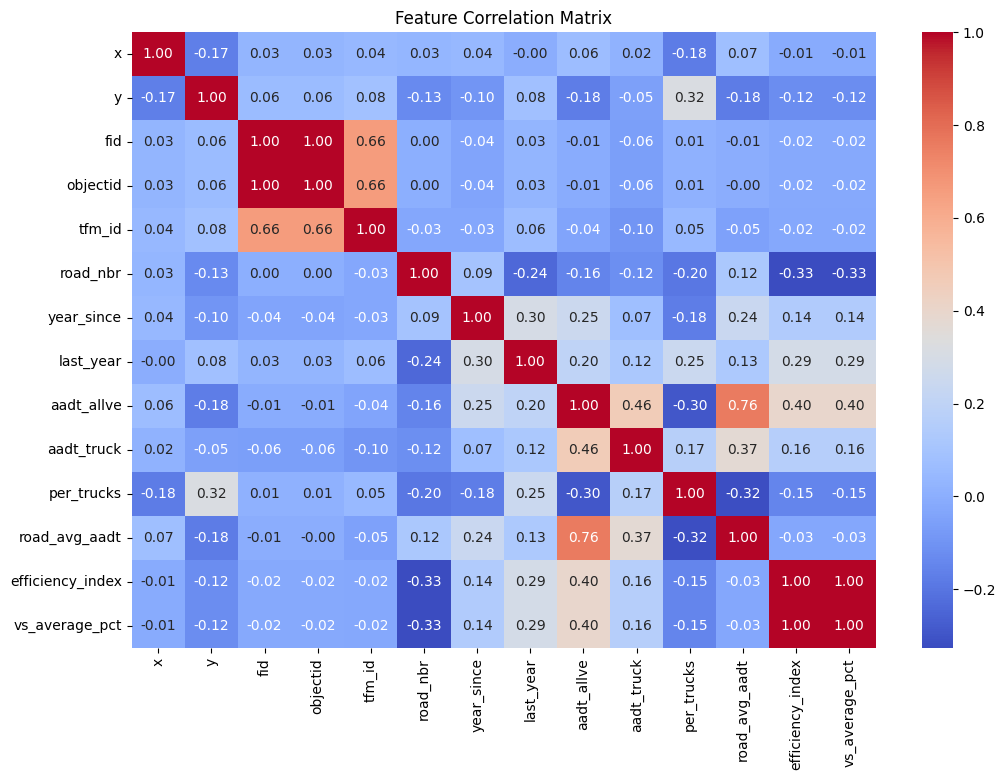

In [8]:
folder_path = '../Figures/'

#-- Correlation Matric. --#
plt.figure(figsize=(12, 8))
correlation_matrix = df.corr(numeric_only=True)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')\

corr_path = os.path.join(folder_path, "feature_correlation.png")
plt.savefig(corr_path, dpi=300, bbox_inches='tight')
print(f"✅ Save correelation matrix at: {corr_path}")
plt.show()

✅ Đã lưu biểu đồ phân phối tại: ../Figures/target_distribution.png


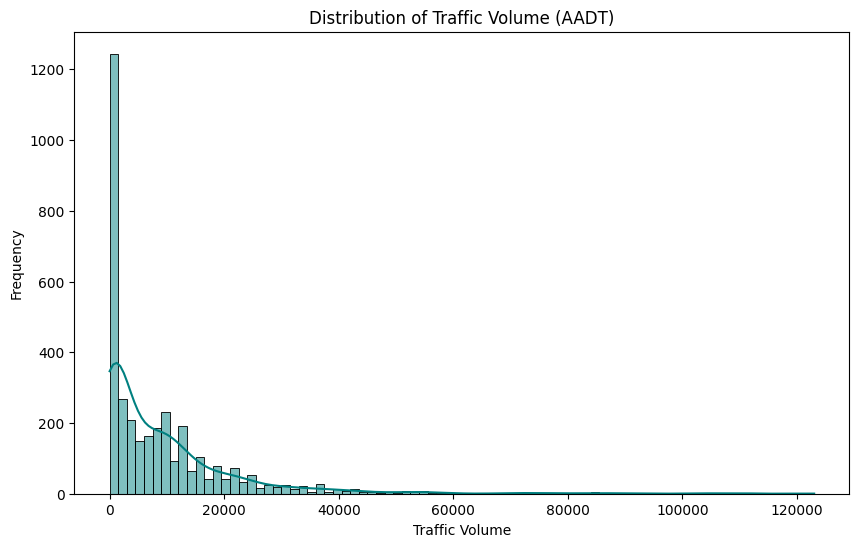

In [9]:
#-- Target Distribution Display. --#
plt.figure(figsize=(10, 6))
sns.histplot(df['aadt_allve'], kde=True, color='teal')
plt.title('Distribution of Traffic Volume (AADT)')
plt.xlabel('Traffic Volume')
plt.ylabel('Frequency')

dist_path = os.path.join(folder_path, "target_distribution.png")
plt.savefig(dist_path, dpi=300, bbox_inches='tight')
print(f"✅ Đã lưu biểu đồ phân phối tại: {dist_path}")
plt.show()

✅ Đã lưu biểu đồ Boxplot tại: ../Figures/features_boxplot.png


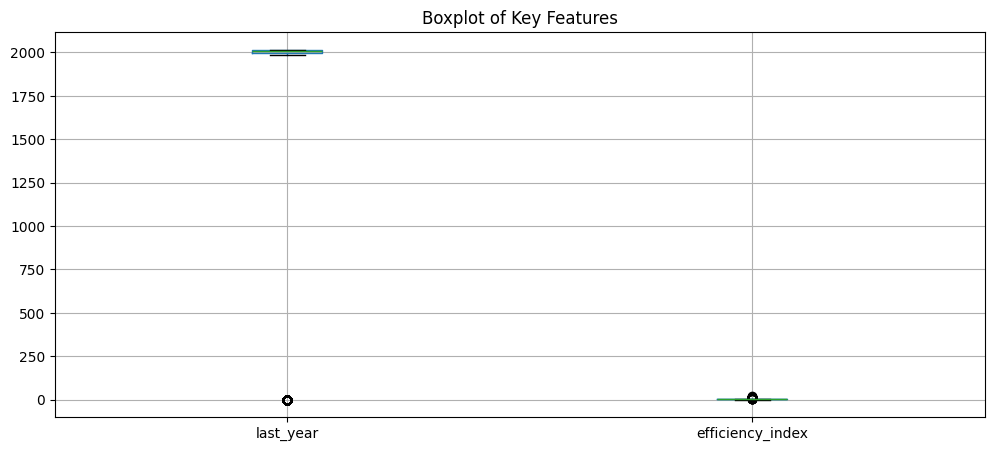

In [10]:
important_features = ['last_year', 'efficiency_index']
plt.figure(figsize=(12, 5))
df[important_features].boxplot()
plt.title('Boxplot of Key Features')

# Lưu hình
box_path = os.path.join(folder_path, "features_boxplot.png")
plt.savefig(box_path, dpi=300, bbox_inches='tight')
print(f"✅ Đã lưu biểu đồ Boxplot tại: {box_path}")
plt.show()

✅ Distribution plot saved successfully to: ../Figures/target_distribution_comparison.png


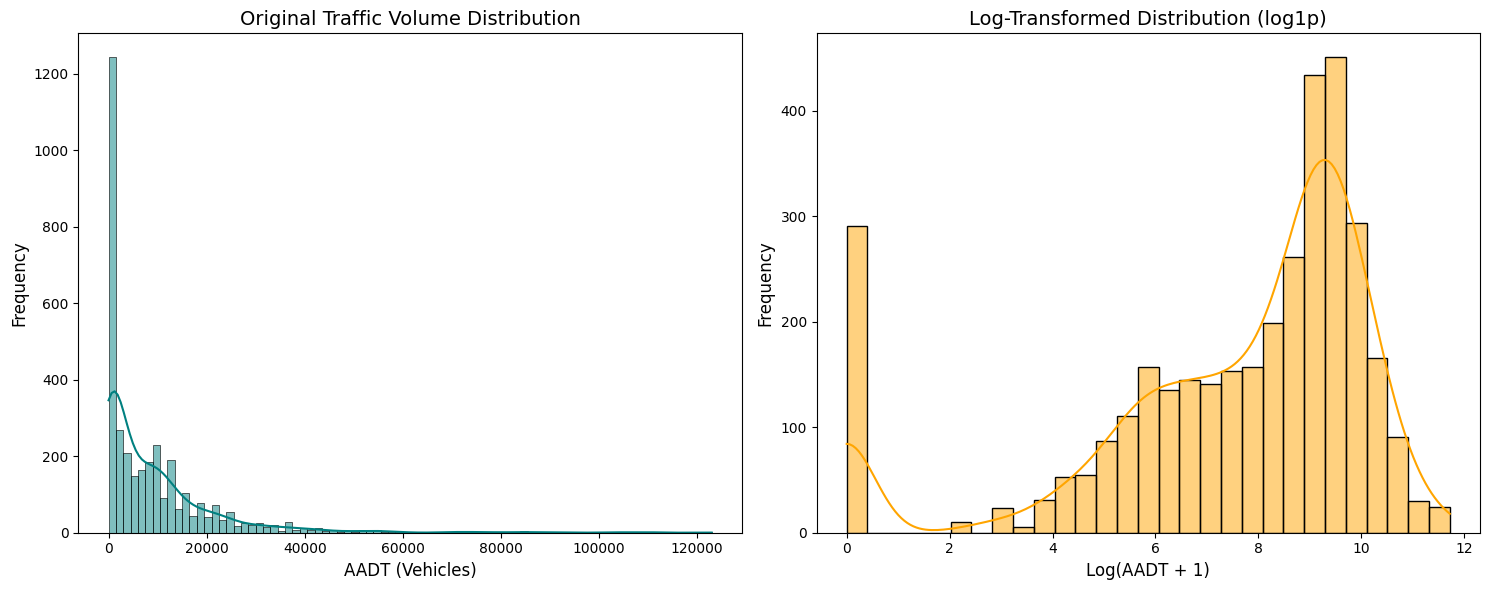

In [11]:
# -- Input folder and target column. --#
target_col = 'aadt_allve'
output_folder = "../Figures/"

#-- Create a side-by-side comparison (Original vs. Log-Transformed). --#
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

#-- Original Distribution. --#
sns.histplot(df[target_col], kde=True, color='teal', ax=axes[0])
axes[0].set_title('Original Traffic Volume Distribution', fontsize=14)
axes[0].set_xlabel('AADT (Vehicles)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)

#-- Log-Transformed Distribution. --#
sns.histplot(np.log1p(df[target_col]), kde=True, color='orange', ax=axes[1])
axes[1].set_title('Log-Transformed Distribution (log1p)', fontsize=14)
axes[1].set_xlabel('Log(AADT + 1)', fontsize=12)
axes[1].set_ylabel('Frequency', fontsize=12)

plt.tight_layout()

#-- Save the figure to your Figures folder. --#
dist_plot_path = os.path.join(output_folder, "target_distribution_comparison.png")
plt.savefig(dist_plot_path, dpi=300)

print(f"✅ Distribution plot saved successfully to: {dist_plot_path}")
plt.show()

### Step 3: Data Processing and Squence Creation ###

In [23]:
#-- Using spatial coordinates (x, y), time (year), and efficiency metrics. --#
feature_columns = ['x', 'y', 'last_year', 'efficiency_index']
target_column = 'aadt_allve'

#-- Data Cleaning. --#
df_clean = df.dropna(subset=feature_columns + [target_column]).copy()

#-- Feature and Target Extraction. --#
X_raw = df_clean[feature_columns].values

#-- Applying Log Transformation (log1p) to normalize the skewed traffic data. --#
y_raw = np.log1p(df_clean[target_column].values)

#--  Reshaping for GRU Architecture. --#
X_seq = X_raw.reshape((X_raw.shape[0], 1, X_raw.shape[1]))
y_seq = y_raw

#-- Summary and Verification. --#
print("--- Data Preprocessing Summary ---")
print(f"Total processed samples: {len(df_clean)}")
print(f"X_seq shape (3D Tensor): {X_seq.shape}")
print(f"y_seq shape: {y_seq.shape}")
print("✅ Status: Data successfully formatted for GRU training.")

--- Data Preprocessing Summary ---
Total processed samples: 3380
X_seq shape (3D Tensor): (3380, 1, 4)
y_seq shape: (3380,)
✅ Status: Data successfully formatted for GRU training.


### Step 4: Model COnstruction and Training. ###

In [26]:
from tensorflow.keras.optimizers import Adam

#-- Train-Test Split. --#
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, 
    test_size=0.2, 
    random_state=42
)

#-- Build GRU Model. --#
model = Sequential([
    #-- GRU layer: input_shape is (TimeSteps, Features). --#
    GRU(units=64, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])),
    
    #-- Dropout layer to prevent overfitting by randomly disabling neurons. --#
    Dropout(0.2),
    
    #-- BatchNormalization to stabilize and speed up the training process. --#
    BatchNormalization(),
    
    #-- Final Dense layer to output the predicted traffic volume (Log-scale) --#
    Dense(units=1)
])

#-- Compile the model. --#
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

#-- Set up EarlyStopping. --#
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True,
    verbose=1
)

#-- Execute Model Training. --#
print("--- Starting Model Training ---")
history = model.fit(
    X_train, y_train,
    epochs=100, 
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ Training phase completed!")
model.summary()

--- Starting Model Training ---
Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 62.4807 - mae: 7.5562 - val_loss: 42.1431 - val_mae: 6.1217
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 43.4846 - mae: 6.2100 - val_loss: 22.2491 - val_mae: 4.2824
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 20.7017 - mae: 4.0387 - val_loss: 6.9395 - val_mae: 2.2443
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 8.5331 - mae: 2.4182 - val_loss: 3.6207 - val_mae: 1.6355
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.9246 - mae: 1.9543 - val_loss: 3.4132 - val_mae: 1.5651
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 5.4131 - mae: 1.8623 - val_loss: 3.3673 - val_mae: 1.5374
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 5.3538 - mae: 1.8400 - val_loss: 3.3068 - val_mae: 1.4749
Epoch 8/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 5.0217 - mae: 1.7956 - val_loss: 3.3384 - val_mae: 1.5124
Epoch 9/100
85/85 ━━━━━━━

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 64)             │        13,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 41,029 (160.27 KB)

 Trainable params: 13,633 (53.25 KB)

 Non-trainable params: 128 (512.00 B)

 Optimizer params: 27,268 (106.52 KB)

### Prediction and Traffic Classification ###

In [27]:
#-- Part I: Prediction on Test Set. --#
log_predictions = model.predict(X_test)

#-- Inverse Transformation
#-- Convert log-scale values back to actual vehicle counts (AADT). --#
predicted_aadt = np.expm1(log_predictions).flatten()
actual_aadt = np.expm1(y_test).flatten()

#-- 3. Create a Results DataFrame for analysis. --#
# We extract spatial and efficiency data from the test set (X_test)
results_df = pd.DataFrame({
    'X_Coord': X_test[:, 0, 0],
    'Y_Coord': X_test[:, 0, 1],
    'Year': X_test[:, 0, 2],
    'Efficiency_Index': X_test[:, 0, 3],
    'Actual_Volume': actual_aadt,
    'Predicted_Volume': predicted_aadt
})

#-- 4. Traffic Status Classification Logic. --#
# Defining thresholds for congestion based on Efficiency Index
def get_traffic_label(efficiency):
    if efficiency < 0.8:
        return 'Congested'
    elif 0.8 <= efficiency <= 1.2:
        return 'Stable'
    else:
        return 'Clear'

# Apply the classification to the results
results_df['Traffic_Status'] = results_df['Efficiency_Index'].apply(get_traffic_label)

#-- 5. Calculate Speed Performance Score. --#
# High efficiency usually indicates the road can maintain its design speed
results_df['Flow_Performance_Score'] = results_df['Efficiency_Index'] * 100

#-- 6. Displaying results for congested routes (Hotspots). --#
print("--- Predicted Traffic Hotspots (Congested Routes) ---")
congested_routes = results_df[results_df['Traffic_Status'] == 'Congested']
print(congested_routes.head(10))

#-- 7. Overall Network Summary. --#
print("\n--- Network Classification Summary ---")
print(results_df['Traffic_Status'].value_counts())

22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
--- Predicted Traffic Hotspots (Congested Routes) ---
       X_Coord    Y_Coord    Year  Efficiency_Index  Actual_Volume  \
1   145.146446 -36.982057  1999.0              0.00            0.0   
25  145.373387 -37.855057     0.0              0.00            0.0   
44  144.883490 -37.733804     0.0              0.00            0.0   
48  144.332234 -37.093452     0.0              0.00            0.0   
52  145.293840 -37.795909     0.0              0.00            0.0   
59  143.365768 -36.271278     0.0              0.00            0.0   
63  145.143781 -36.415996  2013.0              0.36          360.0   
64  143.470047 -35.818937     0.0              0.00            0.0   
68  144.960050 -37.825831     0.0              0.00            0.0   
70  145.152739 -37.901674     0.0              0.00            0.0   

    Predicted_Volume Traffic_Status  Flow_Performance_Score  
1        3105.696045      Congested                     0.0  
25         

### Automated Real-Time Update ###

In [4]:
from datetime import datetime

def monitor_traffic_status(model, X_test, df_clean):
    current_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
    print(f"\n[SYSTEM UPDATE] Timestamp: {current_time}")
    
    # - Part 1. Prediction using the GRU model. --#
    log_preds = model.predict(X_test, verbose=0)
    actual_preds = np.expm1(log_preds).flatten()
    
    # - Part 2. Map results back to original Road Names --#
    # Note: We align the last N rows of df_clean with the test set size
    test_indices = df_clean.index[-len(X_test):]
    monitor_df = df_clean.loc[test_indices, ['road_name', 'efficiency_index']].copy()
    monitor_df['Predicted_Volume'] = actual_preds
    
    # - Part 3. Driving Advisory Logic --#
    def get_speed_advice(row):
        eff = row['efficiency_index']
        base_limit = 60 # Default speed limit in km/h
        
        if eff < 0.8:
            return pd.Series(['CONGESTED', f"{base_limit * 0.5:.0f} km/h", "Heavy: Slow down."])
        elif 0.8 <= eff <= 1.2:
            return pd.Series(['STABLE', f"{base_limit * 0.8:.0f} km/h", "Normal: Steady pace."])
        else:
            return pd.Series(['CLEAR', f"{base_limit:.0f} km/h", "Clear: Maintain limit."])

    monitor_df[['Status', 'Speed_Advice', 'Note']] = monitor_df.apply(get_speed_advice, axis=1)
    
    # - Part 4. Display Results --#
    print(f"{'ROAD NAME':<30} | {'STATUS':<10} | {'ADVICE':<10} | {'GUIDANCE'}")
    print("-" * 85)
    for _, row in monitor_df.head(10).iterrows():
        print(f"{str(row['road_name'])[:30]:<30} | {row['Status']:<10} | {row['Speed_Advice']:<10} | {row['Note']}")

In [ ]:
import time

#-- Frequency of updates in seconds (600 seconds = 10 minutes). --#
UPDATE_INTERVAL = 600 

print("Starting Live Traffic System... (Press Stop to terminate)")

try:
    while True:
        # Calling the function defined in Cell 1
        monitor_traffic_status(model, X_test, df_clean)
        
        print(f"\n[WAITING] Next update in {UPDATE_INTERVAL/60} minutes.")
        time.sleep(UPDATE_INTERVAL)
        
except KeyboardInterrupt:
    print("\n[STOPPED] Monitoring system terminated by user.")